In [8]:
# import libraries

import pandas as pd
import numpy as np
from sklearn.manifold import TSNE 
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import random

In [2]:
# read data
iris = pd.read_csv("iris.txt", sep = ' ', header = None)
images = pd.read_csv("images.txt", header = None)

In [22]:
# Normalize and dimensionality reduction

def preProcess(data):
    
    # normalize data
    data_norm = normalize(data)

    # perform dimensionality reduction on the normalized data and return the reduced data
    reduced_data = TSNE(n_components=1).fit_transform(data_norm)

    return reduced_data

In [23]:
data_images = preProcess(images)
data_iris = preProcess(iris)

In [63]:
clean_data_images = []
clean_data_iris = []
for i in range(len(data_images)):
    clean_data_images.append(data_images[i][0])

for i in range(len(data_iris)):
    clean_data_iris.append(data_iris[i][0])

In [196]:
# Implement the KMeans clustering 

class KMeans:
    
    def __init__(self, k=3, return_sse = False):
        self.k = k
        self.return_sse = return_sse 
        
    def fit_predict(self, data):
        self.data = data
        
        # Initialize the centroids 
        self.centroids = self.initialize_centroids()

        while True:
            
            ''' After initializing the centroids, calculate the distance of each sample/row to the centroids
                For every row/sample you should get three distances, one for each centroid'''
            
            distances = self.distances()
            
            # Assign each data point to the cluster represented by the index of its nearest centroid.
            self.cluster_indices = [[] for n in range(self.k)] # Determine the index of the centroid with the minimum distance.

            # loop through each distance for each data point
            for i in range(len(distances)):

                # find the closest centroid
                closest_idx = np.argmin(distances[i])

                # add that data point to the assigned centroid
                self.cluster_indices[closest_idx].append(self.data[i])
            
            self.old_centroids = self.centroids.copy()
            
            
            # Update each centroid by computing the mean of the data points assigned to its cluster.
            for i in range(self.k):
                if(len(self.cluster_indices[i]) != 0):
                    self.centroids[i] = np.mean(self.cluster_indices[i])# mean of the data points in cluster i
             
            ''' Compare whether the old centroids and newly computed centroids are equal, 
            if they are equal terminate the algorithm '''
            # compare here
            if(np.array_equal(self.centroids, self.old_centroids)):
                break
        
        if self.return_sse:
            sse = self.compute_sse()

            return sse

        # arrange new list for cluster assignments
        indices = self.cluster_indices

        # arrange cluster_indices list for prediction values
        self.cluster_indices = np.zeros(len(self.data), dtype=int)

        # for each cluster
        for i in range(len(indices)):
            #for each data point in the  cluster
            for data_point in indices[i]:
                # get the index of the data point in the original data list
                index = np.where(self.data==data_point)

                # for each index (could have 1+ instances)
                for idx in index:
                    # set the new prediction 
                    self.cluster_indices[idx] = i + 1
        
        return self.cluster_indices 
    
    # This method initializes the centroids
    def initialize_centroids(self):
        # initialize centroids using self.data and self.k

        # initialize np.random
        np.random.seed(123)

        # I will use np.random.choice for this
        centroids = np.random.choice(self.data,size=self.k)
        return centroids
    
    
    # This method calculates the distance
    def distances(self):
        # caulcuate distance using self.data and self.centroids

        # I will be using Euclidean Distance
        distances = []
        dist_calc = []

        # Need to use double for loops for euclidean distance

        # for each sample in the data
        for sample in self.data:

            # for each centroid
            for centroid in self.centroids:
                # calc euclidean distance between each centroid and data point
                dist_calc.append(np.linalg.norm(sample - centroid))

            # append the distances for the sample point
            distances.append(dist_calc)
            dist_calc = []
        return distances
     
        
    
    # Compute SSE (Sum of Squared Errors) (Use can implement any objective function of your choice)
    def compute_sse(self):
        # compute sse using self.data, self.cluster_indices, self.k (refer to the formula mentioned in KMeans slides)
        sse = 0
        # for each cluster
        for i in range(self.k):
            # for each data point nearest to cluster
            for data_point in self.cluster_indices[i]:
                # calculate distance of point to the centroid
                sse_cluster = np.linalg.norm(data_point - self.centroids[i])**2
                    
                # add cluster SSE to total SSE
                sse += sse_cluster
        return sse


In [140]:
def plot_sse(sse, K):
    
    # plot of objective function (y-axis) vs. value of K increasing from 2 to 20 in steps of 2 (x-axis)
    plt.plot(K, sse)
    plt.xlabel("Values of K")
    plt.ylabel("SSE Values")
    plt.show()
    

# Objective function vs K for Iris

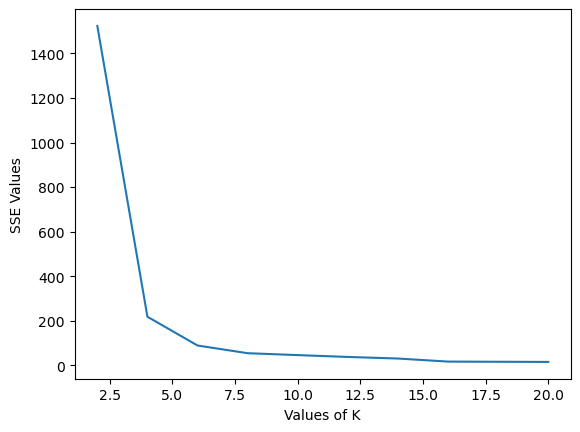

In [197]:
K = [i for i in range(2,21, 2)]
sse = []
for k in K:
    model = KMeans(k = k, return_sse = True)
    sse.append(model.fit_predict(clean_data_iris))
    
plot_sse(sse, K)

# Make cluster assignments for Iris data

In [198]:
# Initialize KMeans class with k = 3 and get the clusters
# Write the clusters to .txt file and upload the file to miner
model = KMeans(k = 3)
predicted_points = model.fit_predict(clean_data_iris)

file = open("predictions.txt", "w")

for pred in predicted_points:
    file.write(str(pred) + "\n")
file.close()

# Objective function vs K for Image data

2
4
6
8
10
12
14
16
18
20


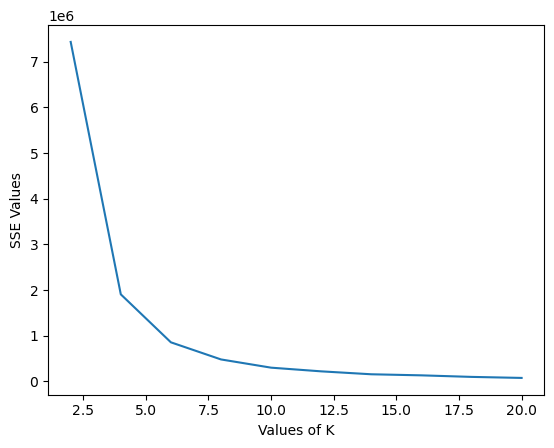

In [193]:
K = [i for i in range(2,21, 2)]
sse = []
for k in K:
    model = KMeans(k = k, return_sse = True)
    sse.append(model.fit_predict(clean_data_images))
    print(k)

plot_sse(sse, K)

# Make cluster assignments for Image data

In [194]:
# Initialize KMeans class with k = 10 and get the clusters
# Write the clusters to .txt file and upload the file to miner
model = KMeans(k = 10)
predicted_points = model.fit_predict(clean_data_images)

file = open("predictions.txt", "w")

for pred in predicted_points:
    file.write(str(pred) + "\n")
file.close()